In [1]:
SEED = 42

In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def header(title, width=80):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def subheader(title, width=80):
    print("\n" + "-" * width)
    print(title.center(width))
    print("-" * width)

def kv(key, value, width=30):
    print(f"{key:<{width}} : {value}")

In [4]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
]

subheader("Загружаем ИИ-тексты")
ai_datasets = pd.DataFrame(columns=["text", "label"])
for fn in filenames:
    df = pd.read_csv(fn, encoding="utf-8").drop_duplicates().assign(label=1)[["text", "label"]].reset_index(drop=True)
    ai_datasets = pd.concat(
        [ai_datasets, df],
        ignore_index=True
    )
    
    print(f"Загружен датасет '{fn}'. {len(df)} записей")
ai_datasets = ai_datasets.drop_duplicates()

subheader("Загружаем живые тексты")
ivy_panda_df = (
    pd.read_csv("../datasets/ivy_panda_essays.csv", encoding="utf-8").drop_duplicates()
    .assign(label=0)[["text", "label"]]
    .sample(n=len(ai_datasets), random_state=SEED)
    .reset_index(drop=True)
)
print(f"Загружен датасет 'ivy_panda_essays'. {len(ivy_panda_df)} записей")


--------------------------------------------------------------------------------
                              Загружаем ИИ-тексты                               
--------------------------------------------------------------------------------
Загружен датасет '../datasets/mistral_essays_1.csv'. 1000 записей
Загружен датасет '../datasets/mistral_essays_2.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_3.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_4.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_5.csv'. 1500 записей
Загружен датасет '../datasets/llama_essays_1.csv'. 999 записей
Загружен датасет '../datasets/llama_essays_2.csv'. 1000 записей
Загружен датасет '../datasets/llama_essays_3.csv'. 994 записей
Загружен датасет '../datasets/llama_essays_4.csv'. 997 записей
Загружен датасет '../datasets/llama_essays_5.csv'. 999 записей
Загружен датасет '../datasets/chatgpt_essays_1.csv'. 2000 записей
Загружен датасет '../datasets/chatgpt_essays

In [5]:
df = (
    pd.concat([ivy_panda_df, ai_datasets], ignore_index=True)
    .sample(frac=1, random_state=SEED).reset_index(drop=True)
)

X = df["text"].astype(str)
y = df["label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

subheader("DATA SPLIT")
kv("Total samples", len(df))
kv("Train", f"{len(X_train)}\t({len(X_train)/len(df):.0%})\t - {sum(y_train)} синтетических")
kv("Test", f"{len(X_test)}\t({len(X_test)/len(df):.0%})\t - {sum(y_test)} синтетических")


--------------------------------------------------------------------------------
                                   DATA SPLIT                                   
--------------------------------------------------------------------------------
Total samples                  : 73976
Train                          : 51783	(70%)	 - 25892 синтетических
Test                           : 22193	(30%)	 - 11096 синтетических


In [6]:
def calculate(X_train, y_train, X_test, y_test):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("clf", LogisticRegression(
            random_state=SEED,
            solver="saga",
            max_iter=5000
        )),
    ])
    
    param_grid = {
        "tfidf__max_features": [25000, 35000],
        "clf__C": [1, 10],
        "clf__l1_ratio": [0, 1]  # 0=L2, 1=L1
    }
    
    subheader("HYPERPARAMETER TUNING")
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_macro",
        verbose=0,
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    kv("GridSearch time (s)", f"{elapsed:.2f}")
    kv("Best CV accuracy", f"{grid_search.best_score_:.4f}")
    kv("Best parameters", grid_search.best_params_)
    
    subheader("CROSS-VALIDATION RESULTS (TOP 5)")
    results_df = (
        pd.DataFrame(grid_search.cv_results_)
        .assign(
            max_features=lambda d: d["param_tfidf__max_features"],
            C=lambda d: d["param_clf__C"],
            l1_ratio=lambda d: d["param_clf__l1_ratio"],
            CV_Accuracy=lambda d: d["mean_test_score"]
        )
        .sort_values("CV_Accuracy", ascending=False)
        [["max_features", "C", "l1_ratio", "CV_Accuracy"]]
        .head(5)
    )
    
    print(results_df.to_string(index=False, float_format="%.4f"))
    
    best_model = grid_search.best_estimator_
    
    vectorizer = best_model.named_steps['tfidf']
    clf = best_model.named_steps['clf']
    
    feature_names = vectorizer.get_feature_names_out()
    coef = clf.coef_[0]
    
    top_words = feature_names[np.argsort(coef)[-25:]]
    print("\nТоп слов для СГЕНЕРИРОВАННЫХ текстов:")
    print(*top_words)
    
    bottom_words = feature_names[np.argsort(coef)[:25]]
    print("\nТоп слов для ЖИВЫХ текстов:")
    print(*bottom_words)
    
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    
    subheader("ЛУЧШАЯ МОДЕЛЬ")
    kv("Train accuracy", f"{train_acc:.4f}")
    kv("Test accuracy", f"{test_acc:.4f}")

    y_test_proba = best_model.predict_proba(X_test)[:, 1]  # вероятность класса 1

    auprc = average_precision_score(y_test, y_test_proba)
    auroc = roc_auc_score(y_test, y_test_proba)

    kv("AUPRC (Test)", f"{auprc:.4f}")
    kv("AUROC (Test)", f"{auroc:.4f}")
    
    subheader("ИТОГО (TEST)")
    y_test_pred = best_model.predict(X_test)
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=["Human Text", "Generated Text"]
    ))
    
    subheader("CONFUSION MATRIX (TEST)")
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "Generated"],
        yticklabels=["Human", "Generated"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix")
    plt.show()

    return best_model


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------


/opt/anaconda3/envs/m2gpu/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch time (s)            : 1397.10
Best CV accuracy               : 0.9980
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 0, 'tfidf__max_features': 35000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        35000 10         0       0.9980
        25000 10         0       0.9980
        35000  1         0       0.9964
        25000  1         0       0.9962
        25000 10         1       0.9958

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
furthermore leading consequences www https www serves typically context potential broader ongoing challenges crucial particularly background context https understanding including profound essay complex essential significant conclusion ultimately

Топ слов для ЖИВЫХ текстов:
web people used differe

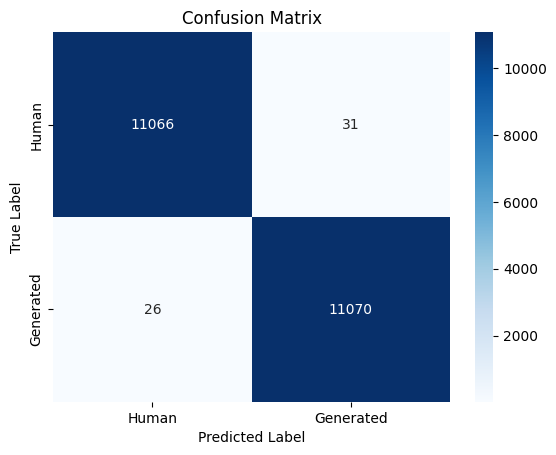

In [7]:
best_model = calculate(X_train, y_train, X_test, y_test)

## Shuffled labels

Перемешаем метки для train, чтобы убедиться в отсутствии утечек. Метрики должны упасть до случайных (~0.50)


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------


/opt/anaconda3/envs/m2gpu/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch time (s)            : 5412.91
Best CV accuracy               : 0.5016
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 0, 'tfidf__max_features': 25000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        25000 10         0       0.5016
        25000 10         1       0.5009
        35000 10         0       0.4998
        35000 10         1       0.4998
        25000  1         0       0.4995

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
implementation process exploits navigating complex substitution admitting gently improve quality ends york city entails changing business white man optical internal communication sentiments critiquing bright tender tourism hospitality cosmetics canadians diction interviewed stressful concentration

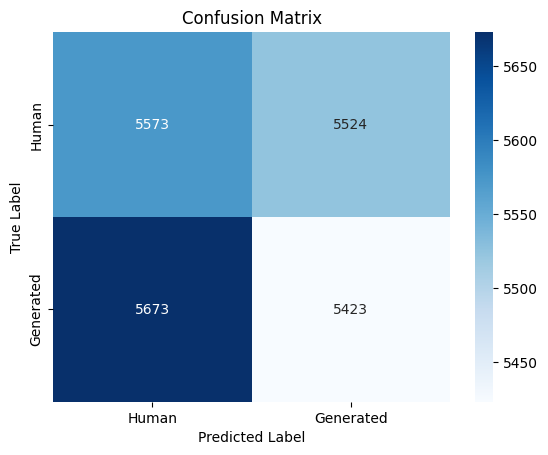

In [8]:
y_train_shuffled = np.random.permutation(y_train)
_ = calculate(X_train, y_train_shuffled, X_test, y_test)

## Примеры текстов, классифицированные верно

In [9]:
def explain_prediction(text, model):
    vectorizer = model.named_steps['tfidf']
    clf = model.named_steps['clf']

    X_vec = vectorizer.transform([text])

    coef = clf.coef_[0]

    contribution = X_vec.toarray()[0] * coef
    feature_names = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        'word': feature_names,
        'tfidf': X_vec.toarray()[0],
        'coef': coef,
        'contribution': contribution
    })

    df = df[df.tfidf > 0].sort_values('contribution', ascending=False)

    print(f"Предсказанный класс: {model.predict([text])[0]}")
    print("\nСлова, показывающие, что текст СИНТЕТИЧЕСКИЙ:")
    print(df.head(20)[['word', 'contribution']].to_string(index=False))

    print("\nСлова, показывающие, что текст ЖИВОЙ:")
    print(df.tail(20)[['word', 'contribution']].to_string(index=False))

In [10]:
text = ivy_panda_df['text'].iloc[0]
print(text)

Based on a movie by David lean the book “Pillars of Wisdom” is a reflection of a British soldier, Lawrence of Arabia experiences when he worked with the rebel forces as a liaison officer during the revolt by the Arabs against the Ottoman Turks between 1916 and 1918.

According to the story, just before the World War one, Lawrence as a British official had begun his scholarly work in which he focused on the seven great cities in the Middle East. The consequent event was a break out of wars between the Arabs and the Turks. He then claimed to have spoilt the manuscript containing his work.

The war broke in a location called Wadi Rum also known as the valley of the moon. The location of this place is cut into the granite and sandstorm rock at 60 km south east of Akaba. This wadi is the largest in the city of Jordan with the name originating from an Aromatic meaning “elevated” or “high”. The Arabs continued with their revolt against the Ottoman Turks with the situation worsening and everyw

In [11]:
explain_prediction(text, best_model)

Предсказанный класс: 0

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
        word  contribution
   narrative      0.293633
 alternative      0.134042
     central      0.123542
     ongoing      0.094790
 significant      0.090969
    language      0.084810
       power      0.070515
  challenges      0.068457
    societal      0.061638
      wisdom      0.060604
emancipation      0.059894
     seeking      0.052741
  background      0.052471
    designed      0.051995
    struggle      0.051921
    allowing      0.051322
         led      0.051252
    engaging      0.049428
   rebellion      0.046337
     reality      0.044671

Слова, показывающие, что текст ЖИВОЙ:
     word  contribution
       th     -0.088778
  ottoman     -0.100674
  britain     -0.101981
     used     -0.109595
   middle     -0.116405
according     -0.137498
     book     -0.141692
situation     -0.151680
     east     -0.154106
  british     -0.173748
countries     -0.180401
    arabs     -0.184290
     main   

In [12]:
text = ai_datasets['text'].iloc[0]
print(text)

In the annals of cinematic history, few films have managed to elicit such a profound emotional response from audiences as Steve McQueen's "12 Years a Slave." Released in 2013, this powerful and unflinching drama recounts the true story of Solomon Northup, a free black man from New York who was kidnapped and sold into slavery in the pre-Civil War South. The film's haunting portrayal of human bondage serves as an unsettling reminder of a dark chapter in American history, inviting viewers to confront the harsh realities of slavery and its enduring impact on individuals and society.

At the heart of "12 Years a Slave" is Chiwetel Ejiofor's riveting performance as Solomon Northup, a talented musician and educated man who, despite his privileges, becomes a slave through no fault of his own. The film opens with Northup's kidnapping, which unfolds in a harrowing sequence that leaves little room for doubt about the brutal nature of the slave trade. From this point onwards, viewers are drawn int

In [13]:
explain_prediction(text, best_model)

Предсказанный класс: 1

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
       word  contribution
   powerful      0.253765
    complex      0.238684
   reminder      0.218070
   enduring      0.208921
     serves      0.205299
     impact      0.199445
 ultimately      0.171729
    northup      0.170200
 resistance      0.156837
exploration      0.151759
individuals      0.137368
   profound      0.131870
 resilience      0.127955
  masterful      0.117336
  emotional      0.112466
   striking      0.109186
     offers      0.104219
    viewers      0.098574
 conclusion      0.097051
     brutal      0.096292

Слова, показывающие, что текст ЖИВОЙ:
      word  contribution
   america     -0.042318
    little     -0.042945
understand     -0.044142
     leads     -0.044217
       use     -0.044417
    owners     -0.044541
      time     -0.048013
       men     -0.052571
      film     -0.053935
   depicts     -0.056152
  12 years     -0.061774
     takes     -0.063481
      wife     -0.06

## Примеры текстов, классифицированные не верно

In [21]:
def show_errors(model, X_test, y_test, c=1, n=20):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, c] # класс

    df = pd.DataFrame({
        "text": X_test,
        "y_true": y_test,
        "y_pred": y_pred,
        "p_generated": y_proba
    })

    errors = df[df.y_true != df.y_pred]

    return errors.sort_values("p_generated", ascending=False).head(n)

### Живой текст, принятый за синтетический

In [15]:
errors = show_errors(best_model, X_test, y_test, n=20)
display(errors)

,text,y_true,y_pred,p_generated
28634,Health disparities research in the United Stat...,0,1,0.966454
9825,"Throughout the last year, society has faced th...",0,1,0.920679
34764,Section I\n\nBryophyta (mosses)\n\n * Bryophy...,0,1,0.833689
5015,Widespread slavery is one of the significant r...,0,1,0.803977
71725,"At the onset of the COVID-19 pandemic, nations...",0,1,0.744079
67993,Mythology is commonly considered a primary sys...,0,1,0.735809
70678,Table of Contents\n 1. Introduction\n 2. Syste...,0,1,0.680293
21930,Corporal punishment as a form of disciplinary ...,0,1,0.651182
39404,Creating Visual Displays of Data\n\nDescriptiv...,0,1,0.649393
46628,The rise in the use of social media has create...,0,1,0.640459


In [19]:
text = X_test[28634]
print(text)

Health disparities research in the United States over the past 2 decades has yielded considerable progress and contributed to a developing evidence base for interventions that tackle disparities in health status and access to care. However, health disparity interventions have focused primarily on individual and interpersonal factors, which are often limited in their ability to yield sustained improvements.

Health disparities emerge and persist through complex mechanisms that include socioeconomic, environmental, and system-level factors. To accelerate the reduction of health disparities and yield enduring health outcomes requires broader approaches that intervene upon these structural determinants. Although an increasing number of innovative programs and policies have been deployed to address structural determinants, few explicitly focused on their impact on minority health and health disparities.

Structural interventions often evolve in response to emerging policy, funding, or polit

In [20]:
explain_prediction(text, best_model)

Предсказанный класс: 1

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
       word  contribution
   powerful      0.253765
    complex      0.238684
   reminder      0.218070
   enduring      0.208921
     serves      0.205299
     impact      0.199445
 ultimately      0.171729
    northup      0.170200
 resistance      0.156837
exploration      0.151759
individuals      0.137368
   profound      0.131870
 resilience      0.127955
  masterful      0.117336
  emotional      0.112466
   striking      0.109186
     offers      0.104219
    viewers      0.098574
 conclusion      0.097051
     brutal      0.096292

Слова, показывающие, что текст ЖИВОЙ:
      word  contribution
   america     -0.042318
    little     -0.042945
understand     -0.044142
     leads     -0.044217
       use     -0.044417
    owners     -0.044541
      time     -0.048013
       men     -0.052571
      film     -0.053935
   depicts     -0.056152
  12 years     -0.061774
     takes     -0.063481
      wife     -0.06

### Синтетический текст, принятый за живой

In [22]:
errors = show_errors(best_model, X_test, y_test, c=0, n=20)
display(errors)

,text,y_true,y_pred,p_generated
51663,When I think about the diversity in American s...,1,0,0.995730
5160,"According to the Bible, homosexuality is consi...",1,0,0.961636
42103,Filling out living will and power of attorney ...,1,0,0.928585
3296,"In the book of Songs of Solomon, also known as...",1,0,0.904681
58371,"In our increasingly digital world, the combina...",1,0,0.830649
28921,The concept of family has been subject to nume...,1,0,0.800486
29619,Macroeconomics is the study of economic phenom...,1,0,0.773905
58382,I have completed a comparative microscopic exa...,1,0,0.732800
12271,The cultural identity and international image ...,1,0,0.725216
52345,In the case study concerning the dismissal of ...,1,0,0.722642


In [26]:
text = X_test[51663]
print(text)

When I think about the diversity in American society, I realize how much it shapes our everyday lives in ways both big and small. Growing up, I always heard that the United States was a "melting pot," and I saw examples of this around me, but it was only later that I really understood what it meant. Living in a country where people come from many cultures, backgrounds, and beliefs makes daily interactions more interesting and sometimes even challenging.

I remember when I moved to a new school in a different state. At first, I felt nervous because the students there came from many different countries and spoke different languages at home. Some of the foods people brought for lunch were unfamiliar to me, and their family traditions were different from my own. After a while, I learned to appreciate these differences. By trying new foods, asking questions about holidays, and listening to other students’ experiences, I became more open-minded and curious. These interactions taught me to re

In [27]:
explain_prediction(text, best_model)

Предсказанный класс: 0

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
         word  contribution
  experiences      0.356148
  individuals      0.249415
 adaptability      0.246566
       unique      0.219655
  backgrounds      0.214604
      empathy      0.173869
      growing      0.161805
     american      0.156613
     everyday      0.155544
 perspectives      0.146636
  challenging      0.133313
 interactions      0.129189
        daily      0.119399
       shapes      0.114267
    strengths      0.111518
        lives      0.101038
     remember      0.094565
      learned      0.083910
united states      0.077087
   unfamiliar      0.074311

Слова, показывающие, что текст ЖИВОЙ:
       word  contribution
      state     -0.135855
     school     -0.146975
      meant     -0.158055
    realize     -0.159600
      helps     -0.167315
    believe     -0.174951
       view     -0.207311
interesting     -0.244065
      ideas     -0.252506
    society     -0.252559
    country     -